In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## Data preprocessing and exploratory analysis

In [ ]:
from datapreparation import load_and_prepare_data
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
train_ds, val_ds, test_ds, label_list, label2id, id2label = load_and_prepare_data()

README.md:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…): reconstructing file:   0%|          |  0.00B / 26.0MB            

aa_dataset-tickets-multi-lang-5-2-50-ver(…): downloading bytes:           |  0.00B            

(…)set-tickets-german_normalized_50_5_2.csv:   0%|          | 0.00/8.33M [00:00<?, ?B/s]

dataset-tickets-multi-lang-4-20k.csv: reconstructing file:   0%|          |  0.00B / 18.8MB            

dataset-tickets-multi-lang-4-20k.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Filter:   0%|          | 0/61765 [00:00<?, ? examples/s]

Filter:   0%|          | 0/28261 [00:00<?, ? examples/s]

Label distribution (train):
Counter({'Technical Support': 6476, 'Customer Service': 3471, 'Billing and Payments': 2307, 'Sales and Pre-Sales': 655, 'General Inquiry': 340})


In [ ]:
print(f"Length of train_ds: {len(train_ds)}")
print(f"Length of val_ds: {len(val_ds)}")
print(f"Length of test_ds: {len(test_ds)}")
print(f"Length of label_list: {len(label_list)}")
print(f"Length of label2id: {len(label2id)}")
print(f"Length of id2label: {len(id2label)}")


Length of train_ds: 13249
Length of val_ds: 1656
Length of test_ds: 1657
Length of label_list: 5
Length of label2id: 5
Length of id2label: 5


In [ ]:
train_df = train_ds.to_pandas()
train_df.head(5)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Guidance on Investment Data Analytics,Is it possible to receive guidance on optimizi...,We can provide guidance on optimizing investme...,Request,Customer Service,medium,en,400.0,Feedback,Product,Feature,Sales,None,None,None,None
1,None,"Dear customer support, the data analytics tool...","Dear [Name], thank you for reaching out to us ...",Incident,Sales and Pre-Sales,medium,en,400.0,Bug,Performance,IT,Tech Support,None,None,None,None
2,Concern Regarding CRM System Malfunction,"Dear Support Team, our marketing agency is fac...","Hello [Name], thank you for reaching out to us...",Incident,Customer Service,high,en,400.0,Bug,Disruption,IT,Tech Support,None,None,None,None
3,Support for MacBook Air,My MacBook Air experienced a crash while runni...,I am here to assist you with the issue on your...,Incident,Technical Support,low,en,NaN,Crash,Hardware,Support,Issue,Assistance,Log,Information,Convenience
4,Inquiring About Evernote Integrations,"Hello, I am writing to inquire about the integ...","Hello, thank you for reaching out to our Servi...",Request,Technical Support,medium,en,NaN,Product,Integration,Compatibility,Guidance,None,None,None,None


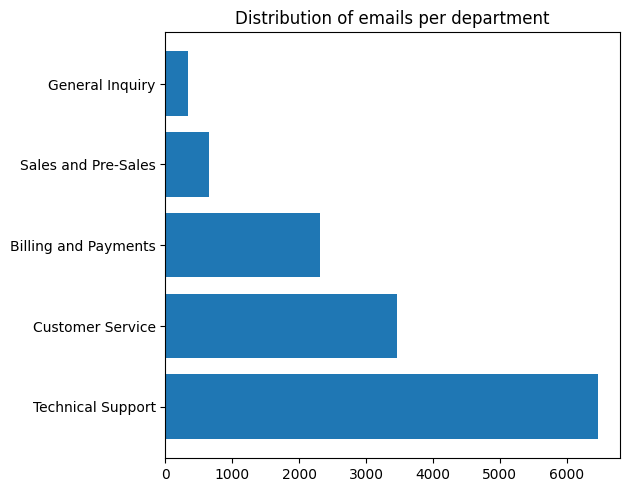

In [ ]:
queue_counts = train_df["queue"].value_counts()
plt.figure()
plt.barh(queue_counts.index, queue_counts.values)
plt.tight_layout()
plt.title("Distribution of emails per department")
plt.show()

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13249 entries, 0 to 13248
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   11547 non-null  object 
 1   body      13249 non-null  object 
 2   answer    13246 non-null  object 
 3   type      13249 non-null  object 
 4   queue     13249 non-null  object 
 5   priority  13249 non-null  object 
 6   language  13249 non-null  object 
 7   version   7593 non-null   float64
 8   tag_1     13249 non-null  object 
 9   tag_2     13241 non-null  object 
 10  tag_3     13194 non-null  object 
 11  tag_4     12045 non-null  object 
 12  tag_5     7614 non-null   object 
 13  tag_6     3660 non-null   object 
 14  tag_7     1705 non-null   object 
 15  tag_8     744 non-null    object 
dtypes: float64(1), object(15)
memory usage: 1.6+ MB


In [ ]:
train_target = train_ds["queue"]

# Data Loading

In [ ]:
from torch.utils.data import Dataset, DataLoader

class EmailRoutingDataset(Dataset):
	def __init__(self, dataset):
		self.dataset = dataset

	def __len__(self):
		return len(self.dataset)

	def __getitem__(self, index):
		row = self.dataset[index]
		subject = "" if row["subject"] is None else str(row["subject"]).strip()
		body = row["body"]
		queue_name = row["queue"]
		label_id = label2id[queue_name]

		combined_text = (
			f"Subject: {subject}\n"
			f"Body: {body}"
		)

		return {
			"subject": subject,
			"body": body,
			"text": combined_text,
			"label": label_id
		}

train_dataset = EmailRoutingDataset(train_ds)
val_dataset = EmailRoutingDataset(val_ds)
test_dataset = EmailRoutingDataset(test_ds)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [ ]:
for batch in test_loader:
	texts = batch["text"]
	true_label_ids = batch["label"]

	print(texts[0])
	print(id2label[true_label_ids[0].item()])
	break

Subject: Encountering Periodic Performance Deterioration
Body: Resolution Required
Customer Service


## Routing with prompting using GPT-2 (frozen model)

Use a pretrained GPT-2 model (the Hugging Face GPT2 “gpt2”) without updating weights.
The model receives an instruction-style prompt containing the task description and
the email text, and must output only the department name.

In [ ]:
import torch
import time
import gc
import numpy as np
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

results = {}

def cuda_sync():
	if torch.cuda.is_available():
		torch.cuda.synchronize()

def start_timer():

	cuda_sync()
	return time.perf_counter()

def stop_timer(start):
	cuda_sync()
	return time.perf_counter() - start

def start_memory_count():

	gc.collect()
	if torch.cuda.is_available():
		torch.cuda.empty_cache()
		torch.cuda.reset_peak_memory_stats()

def gpu_peak_mb():
	if torch.cuda.is_available():
		cuda_sync()
		return torch.cuda.max_memory_allocated() / 1e6
	return np.nan

def clear_cuda():
	gc.collect()
	if torch.cuda.is_available():
		torch.cuda.empty_cache()

def save_result(
	name,
	y_true,
	y_pred,
	inference_seconds,
	training_seconds=0.0,
	inference_memory_mb=np.nan,
	training_memory_mb=np.nan,
):
	acc = accuracy_score(y_true, y_pred)
	results[name] = {
		"accuracy": acc,
		"training_time_s": training_seconds,
		"inference_time_s": inference_seconds,
		"training_peak_cuda_MB": training_memory_mb,
		"inference_peak_cuda_MB": inference_memory_mb,
	}

	print(
		f"{name}: accuracy: {acc:.4f}, "
		f"training: {training_seconds:.2f}s, "
		f"inference: {inference_seconds:.2f}s, "
		f"train peak CUDA: {training_memory_mb:.0f}MB, "
		f"inference peak CUDA: {inference_memory_mb:.0f}MB"
	)


Running on: cuda


In [ ]:
def build_prompt(subject, body):
	return f"""Route the following customer email to exactly one department.

Valid departments:
Technical Support
Customer Service
Billing and Payments
Sales and Pre-Sales
General Inquiry

Subject: {subject}
Body: {body}

Department:"""


def clean_prompt(subject, body):
	subject = "" if subject is None else str(subject).strip()
	body = "" if body is None else str(body).strip()
	return build_prompt(subject, body)

In [ ]:
from contextlib import nullcontext

def mixed_precision_context():
    # A100 supports bfloat16 very efficiently.
    # On CPU we simply run in normal precision.
    if torch.cuda.is_available():
        return torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        )
    return nullcontext()

def parse_prediction(text):
    text = text.strip()
    first_line = text.splitlines()[0].strip() if text else ""

    if first_line in label_list:
        return first_line

    for dept in label_list:
        if dept.lower() in text.lower():
            return dept

    return "__invalid__"

def generate_departments(model, tokenizer, prompts, batch_size=BATCH_SIZE):
    model.eval()
    predictions = []

    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i + batch_size]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        with torch.no_grad(), mixed_precision_context():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=6,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Keep only tokens generated after the prompt.
        new_tokens = output_ids[:, inputs["input_ids"].shape[1]:]
        texts = tokenizer.batch_decode(
            new_tokens,
            skip_special_tokens=True
        )

        predictions.extend(
            parse_prediction(t) for t in texts
        )

    return predictions

@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        batch = {
            k: v.to(device, non_blocking=True)
            for k, v in batch.items()
        }

        with mixed_precision_context():
            loss = model(**batch).loss

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


In [ ]:
true_labels = list(test_ds["queue"])

test_prompts = [
	clean_prompt(subject, body)
	for subject, body in zip(test_ds["subject"], test_ds["body"])
]

print("Number of test prompts:", len(test_prompts))

Number of test prompts: 1657


In [ ]:
# frozen GPT-2 + prompting
from transformers import AutoTokenizer, AutoModelForCausalLM

# tokenizer for GPT-2
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_tokenizer.padding_side = "left"

frozen_gpt2 = AutoModelForCausalLM.from_pretrained("gpt2").to(device)

start_memory_count()
start = start_timer()
frozen_predictions = generate_departments(frozen_gpt2, gpt2_tokenizer, test_prompts)
inference_time = stop_timer(start)
inference_memory = gpu_peak_mb()

save_result(
	"GPT2 prompting",
	true_labels,
	frozen_predictions,
	inference_seconds=inference_time,
	training_seconds=0.0,
	inference_memory_mb=inference_memory,
)

del frozen_gpt2
clear_cuda()


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2 prompting: accuracy: 0.2420, training: 0.00s, inference: 6.44s, train peak CUDA: nanMB, inference peak CUDA: 1609MB


In [ ]:
true_distribution = pd.Series(true_labels).value_counts()
majority_label = true_distribution.index[0]
majority_accuracy = true_distribution.iloc[0] / len(true_labels)
print("Majority class:", majority_label)
print(f"Majority baseline accuracy: {majority_accuracy:.4f}")

Majority class: Technical Support
Majority baseline accuracy: 0.5124


In [ ]:
# DistilGPT2 prompting
distilgpt2_tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
distilgpt2_tokenizer.pad_token = distilgpt2_tokenizer.eos_token
distilgpt2_tokenizer.padding_side = "left"

frozen_distilgpt2 = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)

start_memory_count()
start = start_timer()
frozen_distilgpt2_predictions = generate_departments(
    frozen_distilgpt2, distilgpt2_tokenizer, test_prompts
)
inference_time = stop_timer(start)
inference_memory = gpu_peak_mb()

save_result(
    "DistilGPT2 prompting",
    true_labels,
    frozen_distilgpt2_predictions,
    inference_seconds=inference_time,
    training_seconds=0.0,
    inference_memory_mb=inference_memory,
)

del frozen_distilgpt2
clear_cuda()


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

DistilGPT2 prompting: accuracy: 0.4243, training: 0.00s, inference: 3.25s, train peak CUDA: nanMB, inference peak CUDA: 1163MB


## Method 2 - GPT-2 with LoRA fine-tuning

In [ ]:
from peft import LoraConfig, get_peft_model

# Turn one email into training token ids
def make_training_row(subject, body, dept):
	prompt = clean_prompt(subject, body)
	answer = " " + dept + gpt2_tokenizer.eos_token

	prompt_ids = gpt2_tokenizer(prompt, truncation=True).input_ids
	answer_ids = gpt2_tokenizer(answer, add_special_tokens=False).input_ids

	input_ids = prompt_ids + answer_ids

	labels = [-100] * len(prompt_ids) + answer_ids #cross-entropy loss uses -100 as ignore_index
	return {"input_ids": input_ids, "labels": labels}

subjects = train_ds["subject"]
bodies = train_ds["body"]
queues = train_ds["queue"]

lora_rows = [make_training_row(s, b, d) for s, b, d in zip(subjects, bodies, queues)]


In [ ]:
# Pad a batch so every row has the same length.
# input_ids are padded with the pad token, labels with -100
def collate_lora(batch):
	max_len = max(len(row["input_ids"]) for row in batch)
	input_ids, attention, labels = [], [], []
	pad_id = gpt2_tokenizer.pad_token_id

	for row in batch:
		n_pad = max_len - len(row["input_ids"])
		input_ids.append(row["input_ids"] + [pad_id] * n_pad)
		attention.append([1] * len(row["input_ids"]) + [0] * n_pad)
		labels.append(row["labels"] + [-100] * n_pad)

	return {
		"input_ids": torch.tensor(input_ids),
		"attention_mask": torch.tensor(attention),
		"labels": torch.tensor(labels),
	}

lora_loader = DataLoader(
	lora_rows,
	batch_size=32,
	shuffle=True,
	collate_fn=collate_lora,
)

# Configuration
lora_config = LoraConfig(
	r=8,
	lora_alpha=16,
	lora_dropout=0.05,
	target_modules=["c_attn"],
	task_type="CAUSAL_LM",
)


In [ ]:
from peft import get_peft_model_state_dict, set_peft_model_state_dict
import copy

val_lora_rows = [
	make_training_row(s, b, d)
	for s, b, d in zip(val_ds["subject"], val_ds["body"], val_ds["queue"])
]
val_lora_loader = DataLoader(
	val_lora_rows,
	batch_size=32,
	shuffle=False,
	collate_fn=collate_lora,
)

lora_gpt2 = get_peft_model(
	AutoModelForCausalLM.from_pretrained("gpt2"),
	lora_config
).to(device)
lora_gpt2.print_trainable_parameters()

optimizer = torch.optim.AdamW(lora_gpt2.parameters(), lr=2e-4)

MAX_EPOCHS = 8
PATIENCE = 2
MIN_DELTA = 1e-3

best_val, best_state, epochs_no_improve = float("inf"), None, 0

start_memory_count()
train_start = start_timer()

for epoch in range(MAX_EPOCHS):
	lora_gpt2.train()
	total_loss = 0.0

	for batch in lora_loader:
		batch = {k: v.to(device) for k, v in batch.items()}

		optimizer.zero_grad()
		loss = lora_gpt2(**batch).loss
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	train_loss = total_loss / len(lora_loader)
	val_loss = evaluate_loss(lora_gpt2, val_lora_loader)

	print(
		f"Epoch {epoch + 1}: "
		f"train loss = {train_loss:.4f}   "
		f"val loss = {val_loss:.4f}"
	)

	if val_loss < best_val - MIN_DELTA:
		best_val = val_loss
		best_state = copy.deepcopy(
			get_peft_model_state_dict(lora_gpt2)
		)
		epochs_no_improve = 0
	else:
		epochs_no_improve += 1
		if epochs_no_improve >= PATIENCE:
			print(f"Early stopping at epoch {epoch + 1}")
			break

training_time_gpt2_lora = stop_timer(train_start)
training_memory_gpt2_lora = gpu_peak_mb()

set_peft_model_state_dict(lora_gpt2, best_state)

print(f"Best validation loss: {best_val:.4f}")
print(f"GPT2 + LoRA training time: {training_time_gpt2_lora:.2f}s, "f"peak CUDA memory: {training_memory_gpt2_lora:.0f}MB")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364
Epoch 1: train loss = 0.4848   val loss = 0.2757
Epoch 2: train loss = 0.2899   val loss = 0.2935
Epoch 3: train loss = 0.2784   val loss = 0.2657
Epoch 4: train loss = 0.2716   val loss = 0.2695
Epoch 5: train loss = 0.2675   val loss = 0.2593
Epoch 6: train loss = 0.2636   val loss = 0.2544
Epoch 7: train loss = 0.2603   val loss = 0.2500
Epoch 8: train loss = 0.2564   val loss = 0.2530
Best validation loss: 0.2500
GPT2 + LoRA training time: 930.38s, peak CUDA memory: 22638MB


In [ ]:
start_memory_count()
start = start_timer()

lora_predictions = generate_departments(lora_gpt2,gpt2_tokenizer,test_prompts)

inference_time = stop_timer(start)
inference_memory = gpu_peak_mb()

save_result(
	"GPT2 + LoRA",
	true_labels,
	lora_predictions,
	inference_seconds=inference_time,
	training_seconds=training_time_gpt2_lora,
	inference_memory_mb=inference_memory,
	training_memory_mb=training_memory_gpt2_lora,
)

del lora_gpt2
del optimizer
del best_state
clear_cuda()


GPT2 + LoRA: accuracy: 0.6741, training: 930.38s, inference: 5.82s, train peak CUDA: 22638MB, inference peak CUDA: 1443MB


## Method 3 - DistilGPT2 + LoRA

In [ ]:
lora_distilgpt2 = get_peft_model(
	AutoModelForCausalLM.from_pretrained("distilgpt2"),
	lora_config
).to(device)
lora_distilgpt2.print_trainable_parameters()

optimizer = torch.optim.AdamW(lora_distilgpt2.parameters(), lr=2e-4)

MAX_EPOCHS = 8
PATIENCE = 2
MIN_DELTA = 1e-3
best_val, best_state, epochs_no_improve = float("inf"), None, 0

start_memory_count()
train_start = start_timer()

for epoch in range(MAX_EPOCHS):
	lora_distilgpt2.train()
	total_loss = 0.0

	for batch in lora_loader:
		batch = {k: v.to(device) for k, v in batch.items()}

		optimizer.zero_grad()
		loss = lora_distilgpt2(**batch).loss
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	train_loss = total_loss / len(lora_loader)
	val_loss = evaluate_loss(lora_distilgpt2, val_lora_loader)

	print(
		f"Epoch {epoch + 1}: "
		f"train loss = {train_loss:.4f}   "
		f"val loss = {val_loss:.4f}"
	)

	if val_loss < best_val - MIN_DELTA:
		best_val = val_loss
		best_state = copy.deepcopy(
			get_peft_model_state_dict(lora_distilgpt2)
		)
		epochs_no_improve = 0
	else:
		epochs_no_improve += 1
		if epochs_no_improve >= PATIENCE:
			print(f"Early stopping at epoch {epoch + 1}")
			break

training_time_distilgpt2_lora = stop_timer(train_start)
training_memory_distilgpt2_lora = gpu_peak_mb()

set_peft_model_state_dict(lora_distilgpt2, best_state)

print(f"Best validation loss: {best_val:.4f}")
print(
	f"DistilGPT2 + LoRA training time: "
	f"{training_time_distilgpt2_lora:.2f}s, "
	f"peak CUDA memory: {training_memory_distilgpt2_lora:.0f}MB"
)

# Evaluate
start_memory_count()
start = start_timer()

lora_distilgpt2_predictions = generate_departments(
	lora_distilgpt2,
	distilgpt2_tokenizer,
	test_prompts
)

inference_time = stop_timer(start)
inference_memory = gpu_peak_mb()

save_result(
	"DistilGPT2 + LoRA",
	true_labels,
	lora_distilgpt2_predictions,
	inference_seconds=inference_time,
	training_seconds=training_time_distilgpt2_lora,
	inference_memory_mb=inference_memory,
	training_memory_mb=training_memory_distilgpt2_lora,
)

del lora_distilgpt2
del optimizer
del best_state
clear_cuda()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/peft/mapping_func.py:78: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'gpt2' to 'distilgpt2'. Please ensure that the correct base model is loaded when loading this checkpoint.
  warnings.warn(


trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797
Epoch 1: train loss = 0.5607   val loss = 0.2808
Epoch 2: train loss = 0.2988   val loss = 0.2673
Epoch 3: train loss = 0.2849   val loss = 0.2631
Epoch 4: train loss = 0.2781   val loss = 0.2639
Epoch 5: train loss = 0.2743   val loss = 0.2603
Epoch 6: train loss = 0.2716   val loss = 0.2605
Epoch 7: train loss = 0.2683   val loss = 0.2600
Early stopping at epoch 7
Best validation loss: 0.2603
DistilGPT2 + LoRA training time: 515.86s, peak CUDA memory: 15644MB
DistilGPT2 + LoRA: accuracy: 0.6530, training: 515.86s, inference: 3.34s, train peak CUDA: 15644MB, inference peak CUDA: 1083MB


## Method 4 - DistilBERT classifier

Here we do not generate text. DistilBERT reads the email and outputs a probability for each of the 5 departments; we pick the department with the highest probability.

In [ ]:
# DistilBERT discriminative classifier
from transformers import AutoModelForSequenceClassification

bert_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

# Turn a batch of emails into token ids + the integer label
def collate_bert(batch):
    texts = [row["text"] for row in batch]
    labels = torch.tensor(
        [row["label"] for row in batch],
        dtype=torch.long
    )

    encoded = bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )
    encoded["labels"] = labels
    return encoded

bert_train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_bert,
    pin_memory=torch.cuda.is_available()
)

bert_val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_bert,
    pin_memory=torch.cuda.is_available()
)

bert_test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_bert,
    pin_memory=torch.cuda.is_available()
)

# Classification model with one output per department.
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# training loop for DistilBERT
optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

MAX_EPOCHS = 8
PATIENCE = 2
MIN_DELTA = 1e-3

best_val, best_state, epochs_no_improve = float("inf"), None, 0

start_memory_count()
train_start = start_timer()

for epoch in range(MAX_EPOCHS):
	bert_model.train()
	total_loss = 0.0

	for batch in bert_train_loader:
		batch = {k: v.to(device) for k, v in batch.items()}

		optimizer.zero_grad()
		loss = bert_model(**batch).loss
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	train_loss = total_loss / len(bert_train_loader)
	val_loss = evaluate_loss(bert_model, bert_val_loader)

	print(
		f"Epoch {epoch + 1}: "
		f"train loss: {train_loss:.4f}   "
		f"val loss: {val_loss:.4f}"
	)

	if val_loss < best_val - MIN_DELTA:
		best_val = val_loss
		best_state = {
			k: v.detach().cpu().clone()
			for k, v in bert_model.state_dict().items()
		}
		epochs_no_improve = 0
	else:
		epochs_no_improve += 1
		if epochs_no_improve >= PATIENCE:
			print(f"Early stopping at epoch {epoch + 1}")
			break

training_time_bert = stop_timer(train_start)
training_memory_bert = gpu_peak_mb()

bert_model.load_state_dict(best_state)
bert_model.to(device)

print(f"Best validation loss: {best_val:.4f}")
print(f"DistilBERT training time: {training_time_bert:.2f}s, "f"peak CUDA memory: {training_memory_bert:.0f}MB")


Epoch 1: train loss: 0.9942   val loss: 0.8947
Epoch 2: train loss: 0.8371   val loss: 0.8244
Epoch 3: train loss: 0.7281   val loss: 0.7703
Epoch 4: train loss: 0.5836   val loss: 0.6497
Epoch 5: train loss: 0.4282   val loss: 0.5682
Epoch 6: train loss: 0.3051   val loss: 0.5780
Epoch 7: train loss: 0.2195   val loss: 0.5339
Epoch 8: train loss: 0.1774   val loss: 0.6183
Best validation loss: 0.5339
DistilBERT training time: 417.61s, peak CUDA memory: 9858MB


In [ ]:
bert_model.eval()
bert_predictions = []

start_memory_count()
start = start_timer()

with torch.no_grad():
	for batch in bert_test_loader:
		batch.pop("labels")
		batch = {k: v.to(device) for k, v in batch.items()}

		logits = bert_model(**batch).logits
		predicted_ids = logits.argmax(dim=-1).cpu().tolist()
		bert_predictions.extend(id2label[i] for i in predicted_ids)

inference_time = stop_timer(start)
inference_memory = gpu_peak_mb()

save_result(
	"DistilBERT classifier",
	true_labels,
	bert_predictions,
	inference_seconds=inference_time,
	training_seconds=training_time_bert,
	inference_memory_mb=inference_memory,
	training_memory_mb=training_memory_bert,
)

del bert_model
del optimizer
del best_state
clear_cuda()


DistilBERT classifier: accuracy: 0.8365, training: 417.61s, inference: 2.52s, train peak CUDA: 9858MB, inference peak CUDA: 1726MB


## TF-IDF + Logistic regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

def combine(subject, body):
	subject = "" if subject is None else str(subject)
	body = "" if body is None else str(body)
	return f"Subject: {subject}\nBody: {body}"

train_texts = [
	combine(s, b)
	for s, b in zip(train_ds["subject"], train_ds["body"])
]
test_texts = [
	combine(s, b)
	for s, b in zip(test_ds["subject"], test_ds["body"])
]
train_targets = list(train_ds["queue"])

tfidf_lr = Pipeline([
	("tfidf",TfidfVectorizer(
			max_features=20000,
			ngram_range=(1, 2),
			sublinear_tf=True
		)
	),
	("clf",LogisticRegression(
			max_iter=1000,
			class_weight="balanced"
		)
	),
])

# CPU training time
start = time.perf_counter()
tfidf_lr.fit(train_texts, train_targets)
training_time_tfidf = time.perf_counter() - start

# CPU inference time
start = time.perf_counter()
baseline_predictions = list(tfidf_lr.predict(test_texts))
inference_time_tfidf = time.perf_counter() - start

save_result(
	"TF-IDF + LogReg",
	true_labels,
	baseline_predictions,
	inference_seconds=inference_time_tfidf,
	training_seconds=training_time_tfidf,
	# CUDA memory is not applicable
	inference_memory_mb=np.nan,
	training_memory_mb=np.nan,
)


TF-IDF + LogReg: accuracy: 0.7514, training: 16.78s, inference: 0.23s, train peak CUDA: nanMB, inference peak CUDA: nanMB


## Comparison of the methods

Accuracy, computation time and peak memory for each method on the test set.

In [ ]:
comparison = pd.DataFrame(results).T
comparison = comparison[
	[
		"accuracy",
		"training_time_s",
		"inference_time_s",
		"training_peak_cuda_MB",
		"inference_peak_cuda_MB",
	]
]
comparison


,accuracy,training_time_s,inference_time_s,training_peak_cuda_MB,inference_peak_cuda_MB
GPT2 prompting,0.242004,0.000000,6.443411,NaN,1609.177600
DistilGPT2 prompting,0.424261,0.000000,3.245651,NaN,1163.062784
GPT2 + LoRA,0.674110,930.379049,5.822641,22637.511680,1443.113984
DistilGPT2 + LoRA,0.652987,515.858416,3.342007,15643.642880,1083.378176
DistilBERT classifier,0.836451,417.611172,2.521496,9858.120192,1726.191616
TF-IDF + LogReg,0.751358,16.784804,0.228255,NaN,NaN


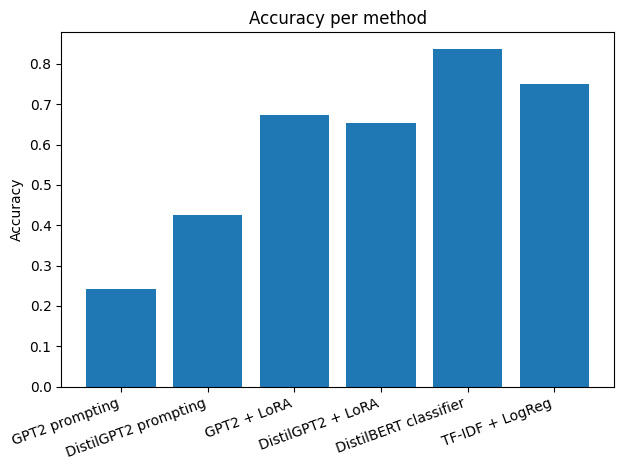

In [ ]:
plt.figure()
plt.bar(comparison.index, comparison["accuracy"])
plt.ylabel("Accuracy")
plt.title("Accuracy per method")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

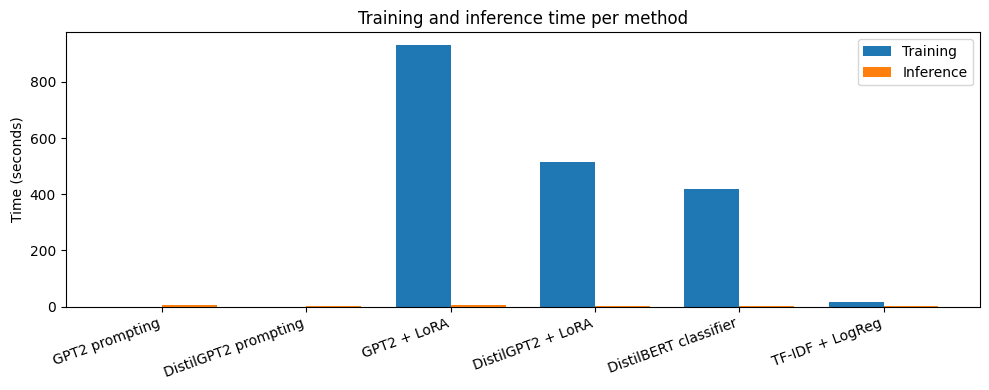

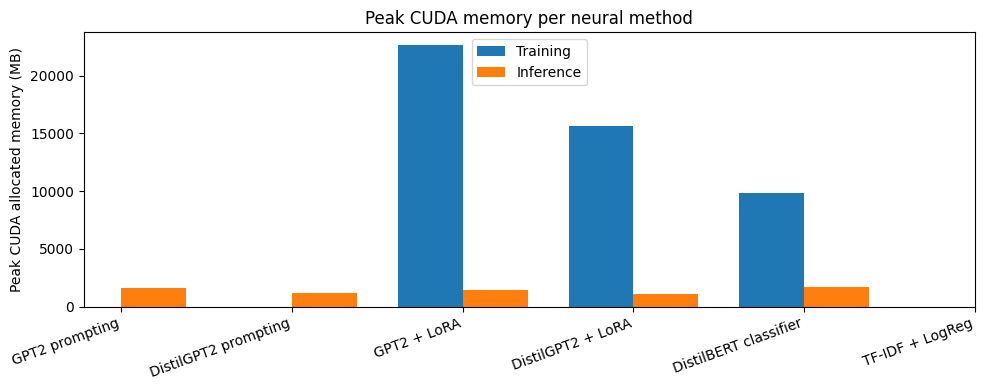

In [ ]:
# Timing comparison.
plt.figure(figsize=(10, 4))
x = np.arange(len(comparison))
width = 0.38

plt.bar(
	x - width / 2,
	comparison["training_time_s"],
	width,
	label="Training"
)
plt.bar(
	x + width / 2,
	comparison["inference_time_s"],
	width,
	label="Inference"
)

plt.ylabel("Time (seconds)")
plt.title("Training and inference time per method")
plt.xticks(x, comparison.index, rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# Peak CUDA memory comparison.
plt.figure(figsize=(10, 4))
plt.bar(
	x - width / 2,
	comparison["training_peak_cuda_MB"],
	width,
	label="Training"
)
plt.bar(
	x + width / 2,
	comparison["inference_peak_cuda_MB"],
	width,
	label="Inference"
)

plt.ylabel("Peak CUDA allocated memory (MB)")
plt.title("Peak CUDA memory per neural method")
plt.xticks(x, comparison.index, rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()



GPT2 prompting:
                      precision    recall  f1-score   support

Billing and Payments      0.000     0.000     0.000       291
    Customer Service      0.226     0.694     0.340       395
     General Inquiry      0.000     0.000     0.000        29
 Sales and Pre-Sales      0.000     0.000     0.000        93
   Technical Support      0.585     0.150     0.238       849

           micro avg      0.280     0.242     0.260      1657
           macro avg      0.162     0.169     0.116      1657
        weighted avg      0.354     0.242     0.203      1657



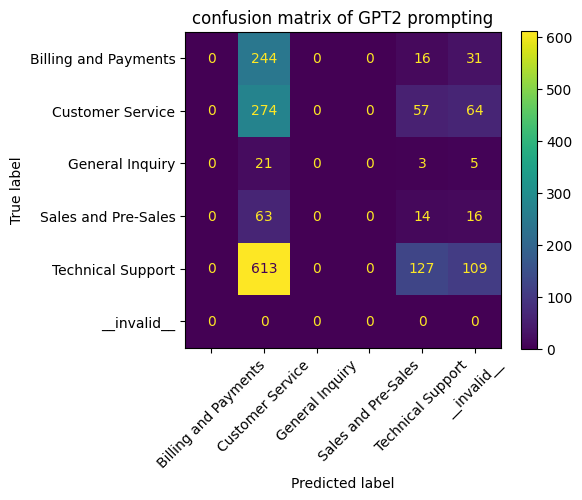

DistillGPT2 prompting:
                      precision    recall  f1-score   support

Billing and Payments      0.000     0.000     0.000       291
    Customer Service      0.232     0.405     0.295       395
     General Inquiry      0.000     0.000     0.000        29
 Sales and Pre-Sales      0.000     0.000     0.000        93
   Technical Support      0.576     0.640     0.606       849

           micro avg      0.431     0.424     0.427      1657
           macro avg      0.162     0.209     0.180      1657
        weighted avg      0.350     0.424     0.381      1657



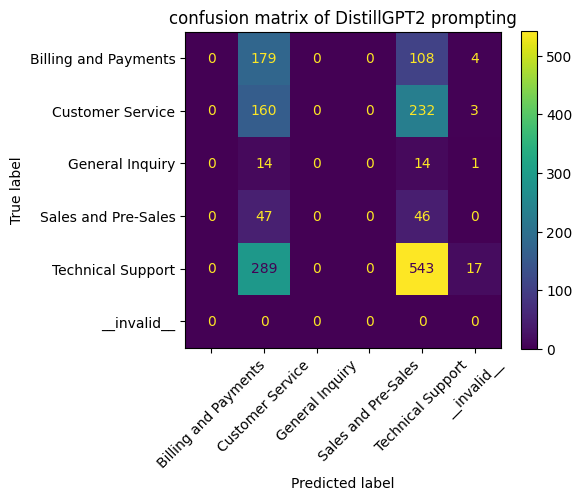

GPT2 + LoRA:
                      precision    recall  f1-score   support

Billing and Payments      0.926     0.691     0.791       291
    Customer Service      0.481     0.385     0.428       395
     General Inquiry      0.000     0.000     0.000        29
 Sales and Pre-Sales      0.857     0.065     0.120        93
   Technical Support      0.679     0.893     0.771       849

            accuracy                          0.674      1657
           macro avg      0.589     0.407     0.422      1657
        weighted avg      0.673     0.674     0.643      1657



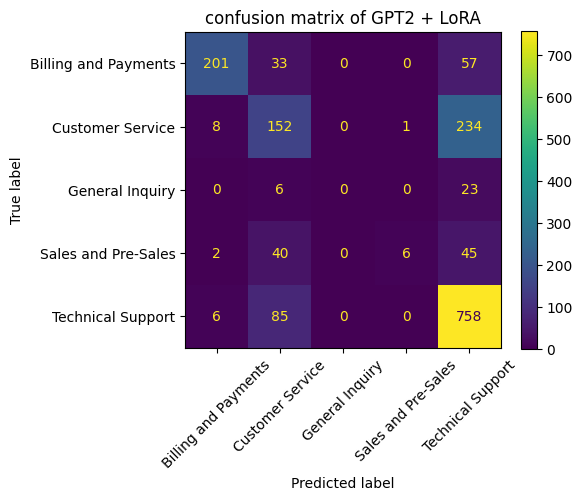

DistillGPT2 + LoRA:
                      precision    recall  f1-score   support

Billing and Payments      0.839     0.698     0.762       291
    Customer Service      0.441     0.273     0.338       395
     General Inquiry      0.000     0.000     0.000        29
 Sales and Pre-Sales      1.000     0.032     0.062        93
   Technical Support      0.658     0.905     0.762       849

            accuracy                          0.653      1657
           macro avg      0.588     0.382     0.385      1657
        weighted avg      0.646     0.653     0.608      1657



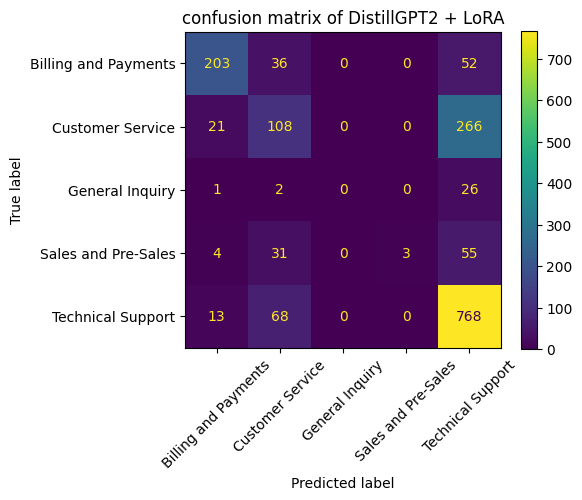

DistilBERT classifier:
                      precision    recall  f1-score   support

Billing and Payments      0.900     0.869     0.885       291
    Customer Service      0.759     0.765     0.762       395
     General Inquiry      0.609     0.483     0.538        29
 Sales and Pre-Sales      0.644     0.602     0.622        93
   Technical Support      0.877     0.896     0.886       849

            accuracy                          0.836      1657
           macro avg      0.758     0.723     0.739      1657
        weighted avg      0.835     0.836     0.835      1657



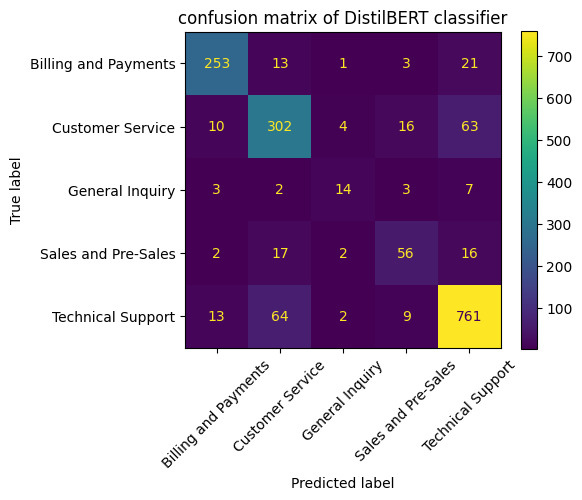

TF-IDF + LogReg:
                      precision    recall  f1-score   support

Billing and Payments      0.875     0.821     0.848       291
    Customer Service      0.604     0.668     0.635       395
     General Inquiry      0.538     0.724     0.618        29
 Sales and Pre-Sales      0.516     0.699     0.594        93
   Technical Support      0.839     0.773     0.804       849

            accuracy                          0.751      1657
           macro avg      0.675     0.737     0.700      1657
        weighted avg      0.766     0.751     0.756      1657



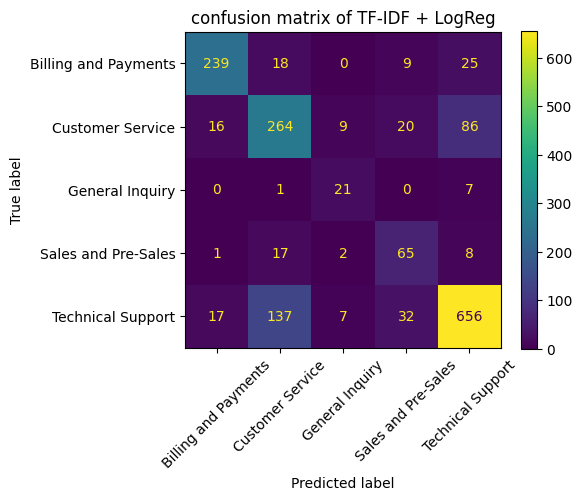

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_predictions(name, y_true, y_pred):
	print(f"{name}:")

	print(classification_report(y_true, y_pred, labels=label_list, digits=3, zero_division=0))
	cm_labels = label_list + (["__invalid__"] if "__invalid__" in y_pred else [])
	cm = confusion_matrix(y_true, y_pred, labels=cm_labels)

	disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cm_labels)
	fig, ax = plt.subplots(figsize=(6, 5))
	disp.plot(ax=ax, xticks_rotation=45)
	ax.set_title(f"confusion matrix of {name}")
	plt.tight_layout()
	plt.show()

evaluate_predictions("GPT2 prompting", true_labels, frozen_predictions)
evaluate_predictions("DistillGPT2 prompting", true_labels, frozen_distilgpt2_predictions)
evaluate_predictions("GPT2 + LoRA", true_labels, lora_predictions)
evaluate_predictions("DistillGPT2 + LoRA", true_labels, lora_distilgpt2_predictions)
evaluate_predictions("DistilBERT classifier", true_labels, bert_predictions)
evaluate_predictions("TF-IDF + LogReg", true_labels, baseline_predictions)